In [1]:
# Auto-reload modules when they change
%load_ext autoreload
%autoreload 2

# make matplotlib render svg
%config InlineBackend.figure_format = 'svg'

import torch
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.utils import load_full_config
from src.mgf_dataset import create_mgf_dataset
from src.mgf_dataset import simulate_ou_process
from src.model import SimpleTransformer

# Compute likelihood of test theta values based on training distribution
from scipy.stats import lognorm
import numpy as np


In [2]:
import pandas as pd

results_path = "../experiments/predictive_test_results_coef0.csv"
results_df = pd.read_csv(results_path)


In [3]:
lengths = results_df.sequence_length.unique()
lengths
results_df

,sweep_name,sequence_length,theta,trained_squared_bias,trained_variance,trained_relative_error,untrained_squared_bias,untrained_variance,untrained_relative_error,num_replicates
0,theta_sweeps,5,0.1000,0.014059,0.927820,0.941879,9.427103,2830.748291,2840.175394,5000
1,theta_sweeps,5,0.2625,0.008367,4.564034,4.572402,2.893401,15578.293945,15581.187346,5000
2,theta_sweeps,5,0.4250,0.000222,10.566583,10.566805,14.395642,51095.488281,51109.883923,5000
3,theta_sweeps,5,0.5875,0.004041,1.819038,1.823079,3.368198,3674.025635,3677.393833,5000
4,theta_sweeps,5,0.7500,0.001034,22.303997,22.305031,5.845923,82080.335938,82086.181860,5000
...,...,...,...,...,...,...,...,...,...,...
220,theta_sweeps,400,3.3500,78.985483,649858.312500,649937.297983,7.209203,6087.246582,6094.455785,5000
221,theta_sweeps,400,3.5125,15.118370,423995.000000,424010.118370,2.377442,3094.052734,3096.430176,5000
222,theta_sweeps,400,3.6750,52.932266,155794.593750,155847.526016,1.480364,1186.523071,1188.003435,5000
223,theta_sweeps,400,3.8375,215.885814,898598.125000,898814.010814,0.102785,9795.222656,9795.325441,5000


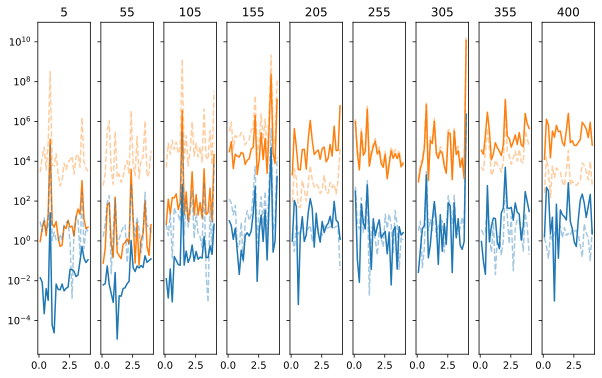

In [4]:


fig,axs = plt.subplots(figsize=(10,6),ncols = len(lengths), sharey=True)

for length in lengths:
    ax = axs[lengths==length][0]
    ax.set_title(f"{length}")
    df = results_df[results_df.sequence_length == length]
    bias = df.trained_squared_bias
    variance = df.trained_variance
    ut_bias = df.untrained_squared_bias
    ut_variance = df.untrained_variance
    theta = df.theta.to_numpy()
    ax.plot(theta, bias,"C0", label="squared bias")
    ax.semilogy(theta, variance , "C1", label="variance")
    ax.plot(theta, ut_bias,"C0--", label="untrained squared bias",alpha=0.4)
    ax.plot(theta, ut_variance, "C1--", label="untrained variance",alpha=0.4)

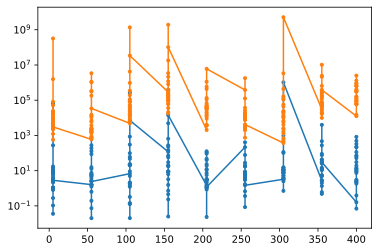

In [5]:
df = results_df[results_df.theta == results_df.theta.unique()[9]]
df = results_df #[results_df.theta == results_df.theta.unique()[9]]
bias = df.trained_squared_bias
variance = df.trained_variance
ut_bias = df.untrained_squared_bias
ut_variance = df.untrained_variance
lengths = df.sequence_length.to_numpy()

fig,ax = plt.subplots(figsize=(6,4))
ax.plot(lengths,  np.abs(bias - ut_bias), "C0.-",label="squared bias")
ax.semilogy(lengths, np.abs(variance - ut_variance), "C1.-",label="variance")

#ax.plot(lengths, ut_bias, "C0+--",label="untrained squared bias")
#ax.semilogy(lengths, ut_variance, "C1+--",label="untrained variance")

In [6]:
# Load variance prediction results (coefficient 1)
variance_results_path = "../experiments/predictive_test_results_coef1.csv"
variance_results_df = pd.read_csv(variance_results_path)

print(f"Variance prediction results shape: {variance_results_df.shape}")
variance_results_df.head()

Variance prediction results shape: (225, 10)


,sweep_name,sequence_length,theta,trained_squared_bias,trained_variance,trained_relative_error,untrained_squared_bias,untrained_variance,untrained_relative_error,num_replicates
0,theta_sweeps,5,0.1000,258.627987,0.108497,258.736484,493.109204,254.993515,748.102719,5000
1,theta_sweeps,5,0.2625,31.994701,0.037862,32.032563,117.898479,93.845566,211.744045,5000
2,theta_sweeps,5,0.4250,10.254512,0.023321,10.277833,63.299876,60.165436,123.465312,5000
3,theta_sweeps,5,0.5875,4.458654,0.017409,4.476063,43.068835,40.684010,83.752844,5000
4,theta_sweeps,5,0.7500,2.210446,0.013797,2.224243,34.333600,31.602793,65.936392,5000


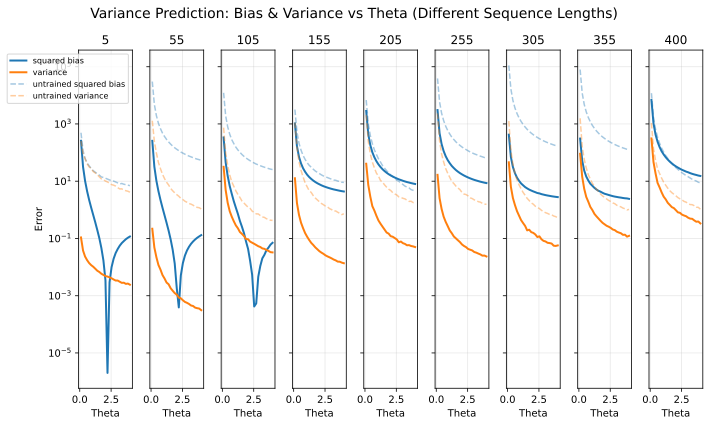

In [7]:
# Plot bias and variance vs theta for different sequence lengths (Variance Prediction)
lengths_var = variance_results_df.sequence_length.unique()

fig, axs = plt.subplots(figsize=(10, 6), ncols=len(lengths_var), sharey=True)
fig.suptitle("Variance Prediction: Bias & Variance vs Theta (Different Sequence Lengths)", fontsize=14)

for i, length in enumerate(lengths_var):
    ax = axs[i] if len(lengths_var) > 1 else axs
    ax.set_title(f"{length}")
    df = variance_results_df[variance_results_df.sequence_length == length]
    
    bias = df.trained_squared_bias
    variance = df.trained_variance
    ut_bias = df.untrained_squared_bias
    ut_variance = df.untrained_variance
    theta = df.theta.to_numpy()
    
    ax.plot(theta, bias, "C0", label="squared bias", linewidth=2)
    ax.semilogy(theta, variance, "C1", label="variance", linewidth=2)
    ax.plot(theta, ut_bias, "C0--", label="untrained squared bias", alpha=0.4)
    ax.plot(theta, ut_variance, "C1--", label="untrained variance", alpha=0.4)
    
    ax.set_xlabel("Theta")
    if i == 0:
        ax.set_ylabel("Error")
        ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()